In [1]:
# Moirai Inference and Visualization

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from huggingface_hub import hf_hub_download
import warnings
warnings.filterwarnings('ignore')

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

# Configuration
MODEL = "moirai"  # or "moirai-moe"
SIZE = "large"    # small, base, large
CTX = 512          # Context length
PDT = 8           # Prediction length
BSZ = 32          # Batch size
GPU = 1           # GPU device
PSZ = "auto"
PSZ_uncertainity = 8
compression_ratio = 0.5

# Data configuration
CSV_PATH = "/home/sa53869/time-series/moirai/time-moe-eval/synthetic_sinusoidal.csv"
COLUMN = 0        # Column to analyze (0-indexed)

# Load Moirai model
print("Loading Moirai model...")
base_module = MoiraiModule.from_pretrained(f"Salesforce/{MODEL}-1.0-R-{SIZE}")

# Test configuration
TEST_LENGTH = 10 # Test set length
TEST_SAMPLES = int(TEST_LENGTH * PDT)  # Number of test samples
NUM_SAMPLES = 1000  # Number of samples for probabilistic forecasting

# Set GPU
os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU)

print(f"Configuration:")
print(f"  Model: {MODEL}-{SIZE}")
print(f"  Context Length: {CTX}")
print(f"  Prediction Length: {PDT}")
print(f"  Test Length: {TEST_LENGTH}")
print(f"  Using GPU: {GPU}")

# Load and prepare data
print("Loading data...")
df = pd.read_csv(CSV_PATH, index_col=0, parse_dates=True)
dataset_name = os.path.splitext(os.path.basename(CSV_PATH))[0]

# Select column
available_columns = df.columns.tolist()
selected_column = available_columns[COLUMN]
df_selected = df[[selected_column]].copy()

print(f"Dataset: {dataset_name}")
print(f"Selected column: {selected_column}")
print(f"Data shape: {df_selected.shape}")
print(f"Data preview:")
print(df_selected.head())

# Create results directory
results_dir = f"results_prune_1/{dataset_name}_{MODEL}-{SIZE}"
os.makedirs(results_dir, exist_ok=True)
print(f"Results will be saved to: {results_dir}")

# Create GluonTS dataset
ds = PandasDataset(dict(df_selected))
train, test_template = split(ds, offset=-TEST_SAMPLES)

# Generate test instances
test_data = test_template.generate_instances(
    prediction_length=PDT,
    windows=TEST_LENGTH,
    distance=PDT,
)

print(f"Number of test windows: {TEST_LENGTH}")


# Create model with specific configuration
model = MoiraiForecast(
    module=base_module,
    prediction_length=PDT,
    context_length=CTX,
    patch_size=PSZ,
    num_samples=NUM_SAMPLES,  # Number of samples for probabilistic forecasting
    target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real,
)

# Create model with reduced context length AND reduced prediction length
reduced_ctx = int(compression_ratio * CTX)
reduced_pdt = max(1, PDT // 2)  # Ensure at least 1 prediction step
model_reduced = MoiraiForecast(
    module=base_module,
    prediction_length=reduced_pdt,
    context_length=reduced_ctx,
    patch_size=PSZ,
    num_samples=NUM_SAMPLES,
    target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real,
)

# Create predictor
predictor = model.create_predictor(batch_size=BSZ)
# Create predictor with reduced context length
predictor_reduced = model_reduced.create_predictor(batch_size=BSZ)
print("Model loaded successfully!")
print(f"Reduced model config: context={reduced_ctx}, prediction={reduced_pdt}")

# Run inference on test data
print("Running inference...")
input_data = list(test_data.input)
label_data = list(test_data.label)

# Create a dataset for the downsampling experiment: downsample the input but not the labels
print("\nPreparing downsampled context data...")
input_data_downsampled = []
for item in tqdm(input_data, desc="Processing downsampled context"):
    # Create a deep copy of the item to avoid modifying original
    downsampled_item = item.copy()
    
    # Replace target with downsampled values based on compression_ratio
    original_target = item['target']
    downsample_step = int(1 / compression_ratio)

    downsampled_target = original_target[::downsample_step]  # Take every Nth sample
    downsampled_item['target'] = downsampled_target

    input_data_downsampled.append(downsampled_item)

# Run predictions with progress bars
print("\nRunning main inference...")
forecasts = list(tqdm(predictor.predict(input_data), desc="Main forecasts", total=len(input_data)))

print("Running downsampled context inference...")
forecasts_downsampled = list(tqdm(predictor_reduced.predict(input_data_downsampled), desc="Downsampled forecasts", total=len(input_data_downsampled)))

print(f"Generated {len(forecasts)} forecasts")

# Prepare data for visualization
print("\nProcessing main results...")
sample_results = []
full_data_values = df_selected[selected_column].values

for i, (input_item, label_item, forecast) in enumerate(tqdm(zip(input_data, label_data, forecasts), desc="Processing main results", total=len(input_data))):
    # Get context data
    context = input_item['target']
    
    # keep the last `CTX` values for context
    if len(context) > CTX:
        context = context[-CTX:]

    # Get ground truth
    ground_truth = label_item['target'][:PDT]
    
    # Get prediction (mean of samples)
    prediction = np.mean(forecast.samples, axis=0)
    
    # Store results
    sample_results.append({
        'window_id': i,
        'context': context,
        'ground_truth': ground_truth,
        'prediction': prediction,
        'mae': np.mean(np.abs(prediction - ground_truth))
    })

print(f"Processed {len(sample_results)} samples")

# repeat for reduced context length
print("\nProcessing downsampled results...")
sample_results_downsampled = []
for i, (input_item, label_item, forecast) in enumerate(tqdm(zip(input_data_downsampled, label_data, forecasts_downsampled), desc="Processing downsampled results", total=len(input_data_downsampled))):
    # Get context data
    context = input_item['target']
    
    # keep the last `reduced_ctx` values for context
    if len(context) > reduced_ctx:
        context = context[-reduced_ctx:]

    # Get ground truth (still full PDT length)
    ground_truth = label_item['target'][:PDT]
    
    # Get prediction (mean of samples) - this is now length reduced_pdt
    prediction_downsampled = np.mean(forecast.samples, axis=0)
    
    # Upsample prediction from reduced_pdt to PDT length using linear interpolation
    if reduced_pdt < PDT:
        # Create indices for original reduced prediction
        reduced_indices = np.linspace(0, PDT-1, reduced_pdt)
        # Create indices for target full prediction
        full_indices = np.arange(PDT)
        # Interpolate to get full-length prediction
        prediction_upsampled = np.interp(full_indices, reduced_indices, prediction_downsampled)
    else:
        prediction_upsampled = prediction_downsampled[:PDT]  # Truncate if somehow longer
    
    # Store results with both reduced and upsampled predictions
    sample_results_downsampled.append({
        'window_id': i,
        'context': context,
        'ground_truth': ground_truth,
        'prediction': prediction_upsampled,  # Upsampled prediction for MAE calculation
        'prediction_downsampled': prediction_downsampled,  # Original reduced prediction
        'prediction_upsampled': prediction_upsampled,  # Upsampled prediction
        'reduced_pdt': reduced_pdt,  # Store reduced prediction length for plotting
        'mae': np.mean(np.abs(prediction_upsampled - ground_truth))  # MAE against full ground truth
    })

# create a new input data with every second value replaced by 0 and then refilled using interpolation
# This maintains the original context length but tests robustness to missing data
print("\nPreparing interpolated context data...")
input_data_reduced_interpolated = []
for item in tqdm(input_data, desc="Processing interpolated context"):
    # Create a deep copy of the item to avoid modifying original
    reduced_item = item.copy()
    
    # Start with original target
    original_target = item['target']
    target_with_zeros = original_target.copy()
    
    # Replace every second value with 0 (creating missing values)
    target_with_zeros[1::2] = 0  # Set every second value to 0
    
    # Create mask for non-zero values (valid data points)
    valid_mask = target_with_zeros != 0
    valid_indices = np.where(valid_mask)[0]
    valid_values = target_with_zeros[valid_mask]
    
    # Interpolate to fill the zero positions
    all_indices = np.arange(len(target_with_zeros))
    interpolated_target = np.interp(all_indices, valid_indices, valid_values)
    
    # Keep the same context length as original
    if len(interpolated_target) > CTX:
        interpolated_target = interpolated_target[-CTX:]
    
    reduced_item['target'] = interpolated_target
    input_data_reduced_interpolated.append(reduced_item)

# Run predictions with interpolated reduced context
print("Running interpolated context inference...")
forecasts_interpolated = list(tqdm(predictor.predict(input_data_reduced_interpolated), desc="Interpolated forecasts", total=len(input_data_reduced_interpolated)))

# Prepare data for visualization with interpolated reduced context
print("\nProcessing interpolated results...")
sample_results_interpolated = []
for i, (input_item, label_item, forecast) in enumerate(tqdm(zip(input_data_reduced_interpolated, label_data, forecasts_interpolated), desc="Processing interpolated results", total=len(input_data_reduced_interpolated))):
    # Get context data
    context = input_item['target']
    
    # Get ground truth
    ground_truth = label_item['target'][:PDT]
    
    # Get prediction (mean of samples)
    prediction = np.mean(forecast.samples, axis=0)
    
    # Store results
    sample_results_interpolated.append({
        'window_id': i,
        'context': context,
        'ground_truth': ground_truth,
        'prediction': prediction,
        'mae': np.mean(np.abs(prediction - ground_truth))
    })

# create a new input data with only the most recent values (truncated context)
# This uses only the most recent data with the reduced model
print("\nPreparing truncated context data...")
input_data_truncated = []
for item in tqdm(input_data, desc="Processing truncated context"):
    # Create a deep copy of the item to avoid modifying original
    truncated_item = item.copy()
    
    # Take only the most recent values to match reduced context length
    original_target = item['target']
    
    # Take the last reduced_ctx values (most recent)
    if len(original_target) > reduced_ctx:
        truncated_target = original_target[-reduced_ctx:]
    else:
        truncated_target = original_target
    
    truncated_item['target'] = truncated_target
    input_data_truncated.append(truncated_item)

# Run predictions with truncated context using reduced model (not main predictor)
print("Running truncated context inference...")
forecasts_truncated = list(tqdm(predictor_reduced.predict(input_data_truncated), desc="Truncated forecasts", total=len(input_data_truncated)))

# Prepare data for visualization with truncated context
print("\nProcessing truncated results...")
sample_results_truncated = []
for i, (input_item, label_item, forecast) in enumerate(tqdm(zip(input_data_truncated, label_data, forecasts_truncated), desc="Processing truncated results", total=len(input_data_truncated))):
    # Get context data
    context = input_item['target']
    
    # Get ground truth (still full PDT length)
    ground_truth = label_item['target'][:PDT]
    
    # Get prediction (mean of samples) - this is now length reduced_pdt
    prediction_truncated = np.mean(forecast.samples, axis=0)
    
    # Store results with both reduced and upsampled predictions
    sample_results_truncated.append({
        'window_id': i,
        'context': context,
        'ground_truth': ground_truth,
        'prediction': prediction_upsampled,  # Upsampled prediction for MAE calculation
        'prediction_truncated': prediction_truncated,  # Original reduced prediction
        'reduced_pdt': reduced_pdt,  # Store reduced prediction length for plotting
        'mae': np.mean(np.abs(prediction_upsampled - ground_truth))  # MAE against full ground truth
    })

# All done
print("Inference and processing complete!")

Loading Moirai model...
Configuration:
  Model: moirai-large
  Context Length: 512
  Prediction Length: 8
  Test Length: 10
  Using GPU: 1
Loading data...
Dataset: synthetic_sinusoidal
Selected column: SIN_WAVE
Data shape: (200000, 1)
Data preview:
                     SIN_WAVE
date                         
2024-01-01 00:00:00  6.000000
2024-01-01 01:00:00  6.870858
2024-01-01 02:00:00  7.666718
2024-01-01 03:00:00  8.319040
2024-01-01 04:00:00  8.771645
Results will be saved to: results_prune_1/synthetic_sinusoidal_moirai-large
Configuration:
  Model: moirai-large
  Context Length: 512
  Prediction Length: 8
  Test Length: 10
  Using GPU: 1
Loading data...
Dataset: synthetic_sinusoidal
Selected column: SIN_WAVE
Data shape: (200000, 1)
Data preview:
                     SIN_WAVE
date                         
2024-01-01 00:00:00  6.000000
2024-01-01 01:00:00  6.870858
2024-01-01 02:00:00  7.666718
2024-01-01 03:00:00  8.319040
2024-01-01 04:00:00  8.771645
Results will be saved to: resu

Processing downsampled context: 100%|██████████| 10/10 [00:00<00:00, 140748.46it/s]



Running main inference...


Main forecasts: 100%|██████████| 10/10 [00:01<00:00,  7.62it/s]


Running downsampled context inference...


...

Running truncated context inference...


Truncated forecasts: 100%|██████████| 10/10 [00:00<00:00, 18.41it/s]



Processing truncated results...


Processing truncated results: 100%|██████████| 10/10 [00:00<00:00, 11861.72it/s]

Inference and processing complete!


In [ ]:
# Implement uncertainty-based pruning methods
# Method 1: Drop least important 50% of samples (shorter context)
# Method 2: Replace least important 50% with interpolation (original length)

print("\n" + "="*60)
print("IMPLEMENTING UNCERTAINTY-BASED PRUNING METHODS")
print("="*60)

# First, create the autoregressive model needed for uncertainty computation
print("Creating autoregressive model for uncertainty computation...")
model_ar = MoiraiForecast(
    module=base_module,
    prediction_length=1,  # Single-step predictions
    context_length=CTX,
    patch_size=PSZ_uncertainity,
    num_samples=NUM_SAMPLES,
    target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real,
)

predictor_ar = model_ar.create_predictor(batch_size=BSZ)
print("Autoregressive predictor created successfully!")

def compute_uncertainty_importance(context_2x, predictor_ar, CTX, template_item):
    """
    Compute uncertainty/importance for each position in the last CTX samples.
    Higher uncertainty = higher importance.
    
    Args:
        context_2x: Array of length 2*CTX containing the last 2*CTX samples
        predictor_ar: Autoregressive predictor for single-step predictions
        CTX: Context length
        template_item: Template item for creating AR predictions
        
    Returns:
        uncertainty_scores: Array of length CTX with uncertainty scores for the last CTX samples
    """
    # Ensure we have exactly 2*CTX samples
    if len(context_2x) != 2*CTX:
        raise ValueError(f"Expected context of length {2*CTX}, got {len(context_2x)}")
    
    # Generate autoregressive predictions for each of the last CTX samples
    # Use sliding windows: predict sample CTX+1 using samples 1:CTX, predict sample CTX+2 using samples 2:CTX+1, etc.
    input_data_context = []
    
    for i in range(CTX):
        # For predicting position CTX+i, use context from position i to CTX+i-1
        context_start = i
        context_end = CTX + i
        context_window = context_2x[context_start:context_end]
        
        # Create input item for this prediction
        ar_item = template_item.copy()
        ar_item['target'] = context_window
        input_data_context.append(ar_item)
    
    # Get predictions for all context windows
    forecasts_ar = list(predictor_ar.predict(input_data_context))
    
    # Compute uncertainty for each position
    uncertainty_scores = []
    for i, forecast in enumerate(forecasts_ar):
        # Get prediction samples for this position
        samples = forecast.samples[:, 0]  # Single-step prediction
        
        # Compute uncertainty as standard deviation of samples
        uncertainty = np.std(samples)
        uncertainty_scores.append(uncertainty)

    return np.array(uncertainty_scores)

# Method 1: Uncertainty-based pruning (drop least important 50%)
print("\nMethod 1: Uncertainty-based pruning (drop least important 50%)")

input_data_uncertainty_short = []
for input_item in tqdm(input_data, desc="Processing uncertainty-based short context"):
    # Get the last 2*CTX samples for uncertainty computation
    original_target = input_item['target']
    
    if len(original_target) < 2*CTX:
        # If we don't have enough data, pad with zeros at the beginning
        padding_needed = 2*CTX - len(original_target)
        padded_target = np.concatenate([np.zeros(padding_needed), original_target])
        context_2x = padded_target
    else:
        # Take the last 2*CTX samples
        context_2x = original_target[-2*CTX:]
    
    # Compute uncertainty for the last CTX samples
    last_ctx_samples = context_2x[-CTX:]  # Only analyze the last CTX samples
    original_last_ctx = last_ctx_samples.copy()
    
    # Compute uncertainty scores using autoregressive predictions
    uncertainty_scores = compute_uncertainty_importance(context_2x, predictor_ar, CTX, input_item)
    
    # Select top 50% most important (highest uncertainty) samples
    num_keep = reduced_ctx  # Use reduced_ctx instead of CTX//2 for consistency
    important_indices = np.argsort(uncertainty_scores)[-num_keep:]  # Get indices of highest uncertainty
    important_indices = np.sort(important_indices)  # Keep them in order
    
    # Create pruned context with only important samples - no padding!
    unc_context = last_ctx_samples[important_indices]
    
    # Create new input item with reduced context
    pruned_item = input_item.copy()
    pruned_item['target'] = unc_context
    input_data_uncertainty_short.append(pruned_item)

print(f"Created {len(input_data_uncertainty_short)} inputs with uncertainty-based pruning (short context)")

# Method 2: Uncertainty-based pruning with interpolation (original CTX length)
print("\nMethod 2: Uncertainty-based pruning with interpolation (original CTX length)")

input_data_uncertainty_interpolated = []
for input_item in tqdm(input_data, desc="Processing uncertainty-based interpolated context"):
    # Get the last 2*CTX samples for uncertainty computation
    original_target = input_item['target']
    
    if len(original_target) < 2*CTX:
        # If we don't have enough data, pad with zeros at the beginning
        padding_needed = 2*CTX - len(original_target)
        padded_target = np.concatenate([np.zeros(padding_needed), original_target])
        context_2x = padded_target
    else:
        # Take the last 2*CTX samples
        context_2x = original_target[-2*CTX:]
    
    # Compute uncertainty for the last CTX samples
    last_ctx_samples = context_2x[-CTX:]  # Only analyze the last CTX samples
    
    # Compute uncertainty scores using autoregressive predictions
    uncertainty_scores = compute_uncertainty_importance(context_2x, predictor_ar, CTX, input_item)
    
    # Replace least important 50% samples with interpolated values
    num_replace = CTX // 2
    least_important_indices = np.argsort(uncertainty_scores)[:num_replace]  # Get indices of lowest uncertainty
    
    # Create interpolated context
    unc_interpolated_context = last_ctx_samples.copy()
    
    # Create mask for interpolation
    unc_interpolated_mask = np.zeros(CTX, dtype=bool)
    unc_interpolated_mask[least_important_indices] = True
    
    # Set least important values to zero temporarily
    target_with_missing = unc_interpolated_context.copy()
    target_with_missing[least_important_indices] = 0
    
    # Interpolate the missing values
    valid_mask = ~unc_interpolated_mask
    valid_indices = np.where(valid_mask)[0]
    valid_values = unc_interpolated_context[valid_mask]
    
    if len(valid_indices) > 1:  # Need at least 2 points for interpolation
        all_indices = np.arange(CTX)
        unc_interpolated_context = np.interp(all_indices, valid_indices, valid_values)
    # If we have too few valid points, keep the original values
    
    # Create new input item
    interpolated_item = input_item.copy()
    interpolated_item['target'] = unc_interpolated_context
    input_data_uncertainty_interpolated.append(interpolated_item)

print(f"Created {len(input_data_uncertainty_interpolated)} inputs with uncertainty-based interpolation")

# Run inference with uncertainty-based pruning methods
print("\nRunning inference with uncertainty-based pruning methods...")

print("Running predictions with uncertainty-based short context...")
forecasts_uncertainty_short = list(tqdm(predictor_reduced.predict(input_data_uncertainty_short), desc="Uncertainty short forecasts", total=len(input_data_uncertainty_short)))

print("Running predictions with uncertainty-based interpolation...")
forecasts_uncertainty_interpolated = list(tqdm(predictor.predict(input_data_uncertainty_interpolated), desc="Uncertainty interpolated forecasts", total=len(input_data_uncertainty_interpolated)))

print(f"Generated {len(forecasts_uncertainty_short)} uncertainty-based short forecasts")
print(f"Generated {len(forecasts_uncertainty_interpolated)} uncertainty-based interpolated forecasts")

# Process results
print("\nProcessing uncertainty-based pruning results...")

# Method 1: Uncertainty-based short results
sample_results_uncertainty_short = []
for i, (input_item, label_item, forecast) in enumerate(tqdm(zip(input_data_uncertainty_short, label_data, forecasts_uncertainty_short), desc="Processing uncertainty short results", total=len(input_data_uncertainty_short))):
    context = input_item['target']
    ground_truth = label_item['target'][:PDT]
    
    # Get prediction (mean of samples) - this is now length reduced_pdt
    prediction_reduced = np.mean(forecast.samples, axis=0)
    
    sample_results_uncertainty_short.append({
        'window_id': i,
        'context': context,
        'ground_truth': ground_truth,
        'prediction': prediction_upsampled,  # Upsampled prediction for MAE calculation
        'prediction_reduced': prediction_truncated,  # Original reduced prediction
        'reduced_pdt': reduced_pdt,  # Store reduced prediction length for plotting
        'mae': np.mean(np.abs(prediction_upsampled - ground_truth))  # MAE against full ground truth
    })

# Method 2: Uncertainty-based interpolated results (unchanged)
sample_results_uncertainty_interpolated = []
for i, (input_item, label_item, forecast) in enumerate(tqdm(zip(input_data_uncertainty_interpolated, label_data, forecasts_uncertainty_interpolated), desc="Processing uncertainty interpolated results", total=len(input_data_uncertainty_interpolated))):
    context = input_item['target']
    ground_truth = label_item['target'][:PDT]
    prediction = np.mean(forecast.samples, axis=0)
    
    # Store interpolation mask if available
    interpolated_mask = np.zeros(len(context), dtype=bool)  # Default to no interpolation
    
    sample_results_uncertainty_interpolated.append({
        'window_id': i,
        'context': context,
        'ground_truth': ground_truth,
        'prediction': prediction,
        'mae': np.mean(np.abs(prediction - ground_truth)),
        'interpolated_mask': interpolated_mask
    })

print(f"Processed {len(sample_results_uncertainty_short)} uncertainty-based short samples")
print(f"Processed {len(sample_results_uncertainty_interpolated)} uncertainty-based interpolated samples")

# Calculate average MAE for all methods
print("\n" + "="*60)
print("SUMMARY OF ALL PRUNING METHODS")
print("="*60)

methods_summary = {
    'Full Context': np.mean([r['mae'] for r in sample_results]),
    'Downsampled (50%)': np.mean([r['mae'] for r in sample_results_downsampled]),
    'Interpolated (50% replaced)': np.mean([r['mae'] for r in sample_results_interpolated]),
    'Truncated (recent values)': np.mean([r['mae'] for r in sample_results_truncated]),
    'Uncertainty-based Short (50% most important)': np.mean([r['mae'] for r in sample_results_uncertainty_short]),
    'Uncertainty-based Interpolated (50% replaced)': np.mean([r['mae'] for r in sample_results_uncertainty_interpolated])
}

print("Method Performance (Mean Absolute Error):")
for method, mae in methods_summary.items():
    print(f"  {method:<40}: {mae:.4f}")

best_method = min(methods_summary.items(), key=lambda x: x[1])
print(f"\nBest performing method: {best_method[0]} (MAE: {best_method[1]:.4f})")


IMPLEMENTING UNCERTAINTY-BASED PRUNING METHODS
Creating autoregressive model for uncertainty computation...
Autoregressive predictor created successfully!

Method 1: Uncertainty-based pruning (drop least important 50%)


Processing uncertainty-based short context:   0%|          | 0/10 [00:00<?, ?it/s]

Processing uncertainty-based short context: 100%|██████████| 10/10 [00:37<00:00,  3.75s/it]


Created 10 inputs with uncertainty-based pruning (short context)

Method 2: Uncertainty-based pruning with interpolation (original CTX length)


Processing uncertainty-based interpolated context: 100%|██████████| 10/10 [00:37<00:00,  3.74s/it]
Processing uncertainty-based interpolated context: 100%|██████████| 10/10 [00:37<00:00,  3.74s/it]


...

Running predictions with uncertainty-based interpolation...


Uncertainty interpolated forecasts: 100%|██████████| 10/10 [00:00<00:00, 15.56it/s]


Generated 10 uncertainty-based short forecasts
Generated 10 uncertainty-based interpolated forecasts

Processing uncertainty-based pruning results...


Processing uncertainty interpolated results: 100%|██████████| 10/10 [00:00<00:00, 14852.35it/s]

Processed 10 uncertainty-based short samples
Processed 10 uncertainty-based interpolated samples

SUMMARY OF ALL PRUNING METHODS
Method Performance (Mean Absolute Error):
  Full Context                            : 0.6153
  Downsampled (50%)                       : 1.2098
  Interpolated (50% replaced)             : 1.1505
  Truncated (recent values)               : 2.0703
  Uncertainty-based Short (50% most important): 2.0703
  Uncertainty-based Interpolated (50% replaced): 1.8270

Best performing method: Full Context (MAE: 0.6153)


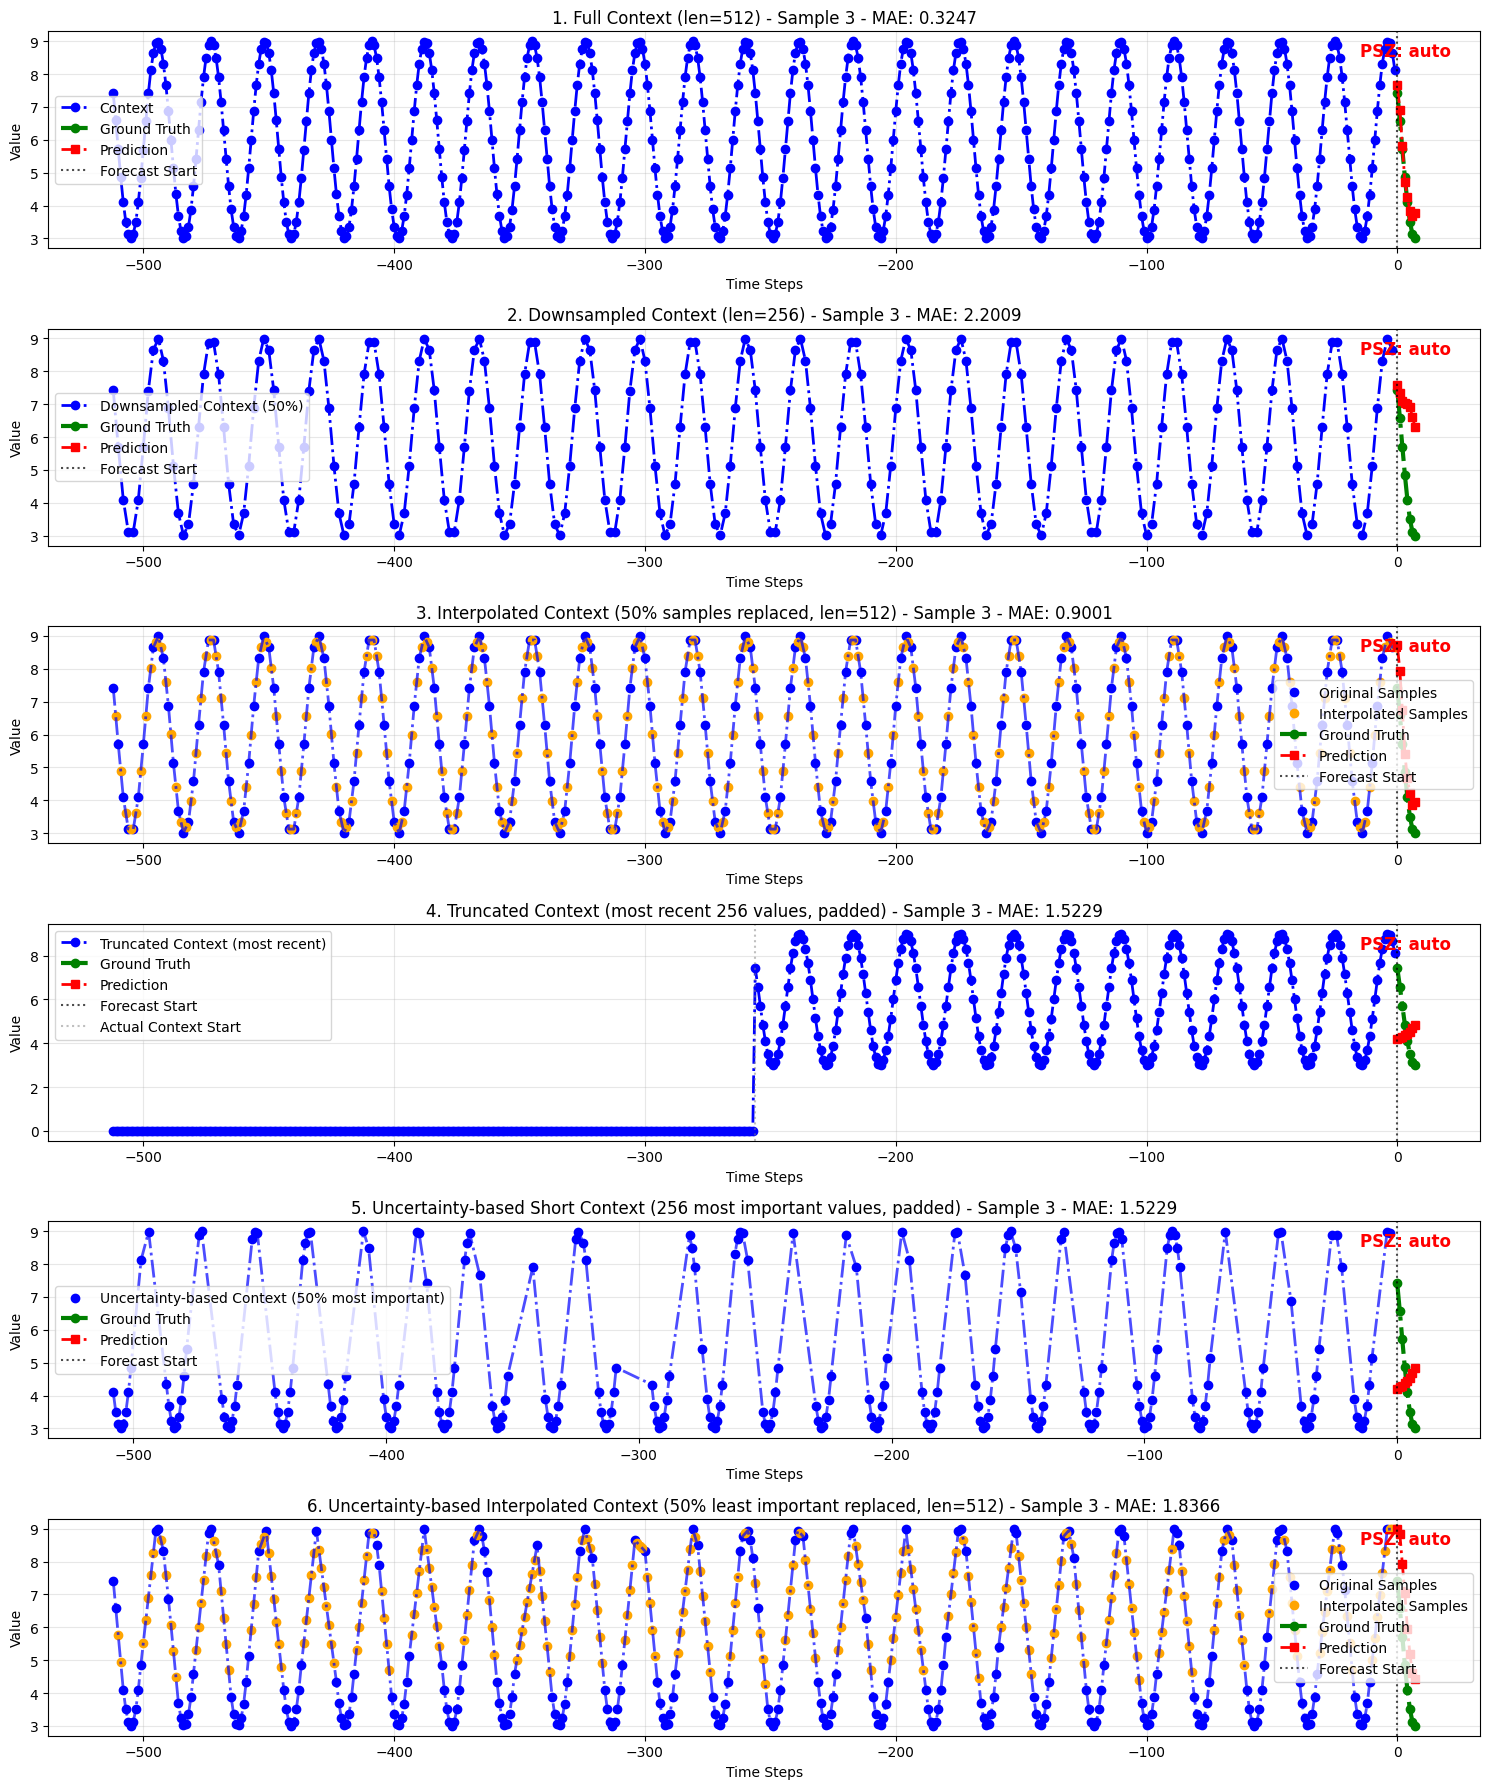

Saved plot: results_prune_1/synthetic_sinusoidal_moirai-large/sample_1_all_methods_comparison.png


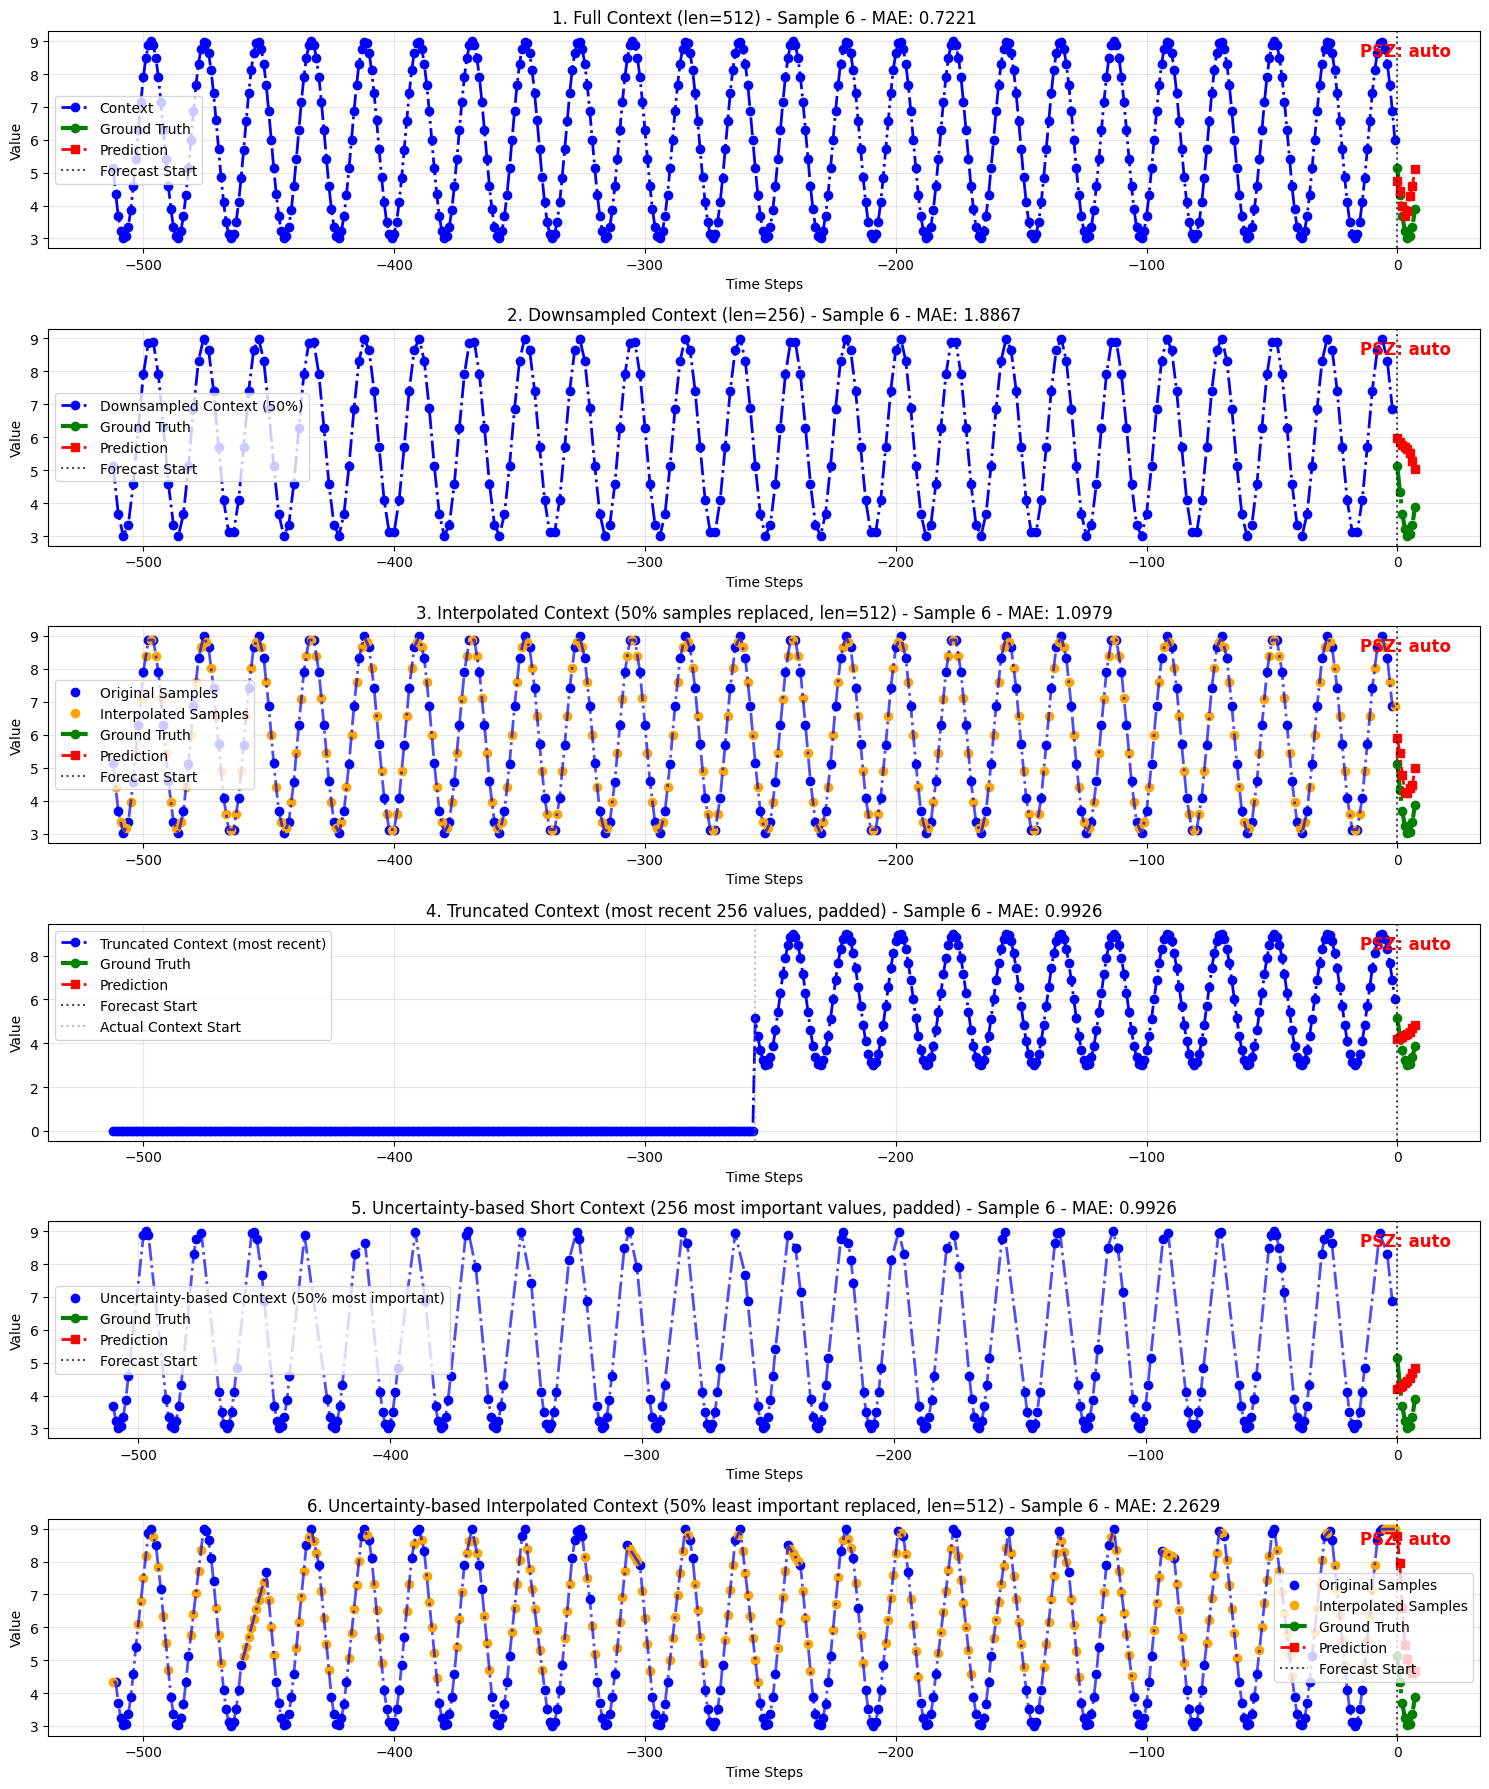

Saved plot: results_prune_1/synthetic_sinusoidal_moirai-large/sample_2_all_methods_comparison.png


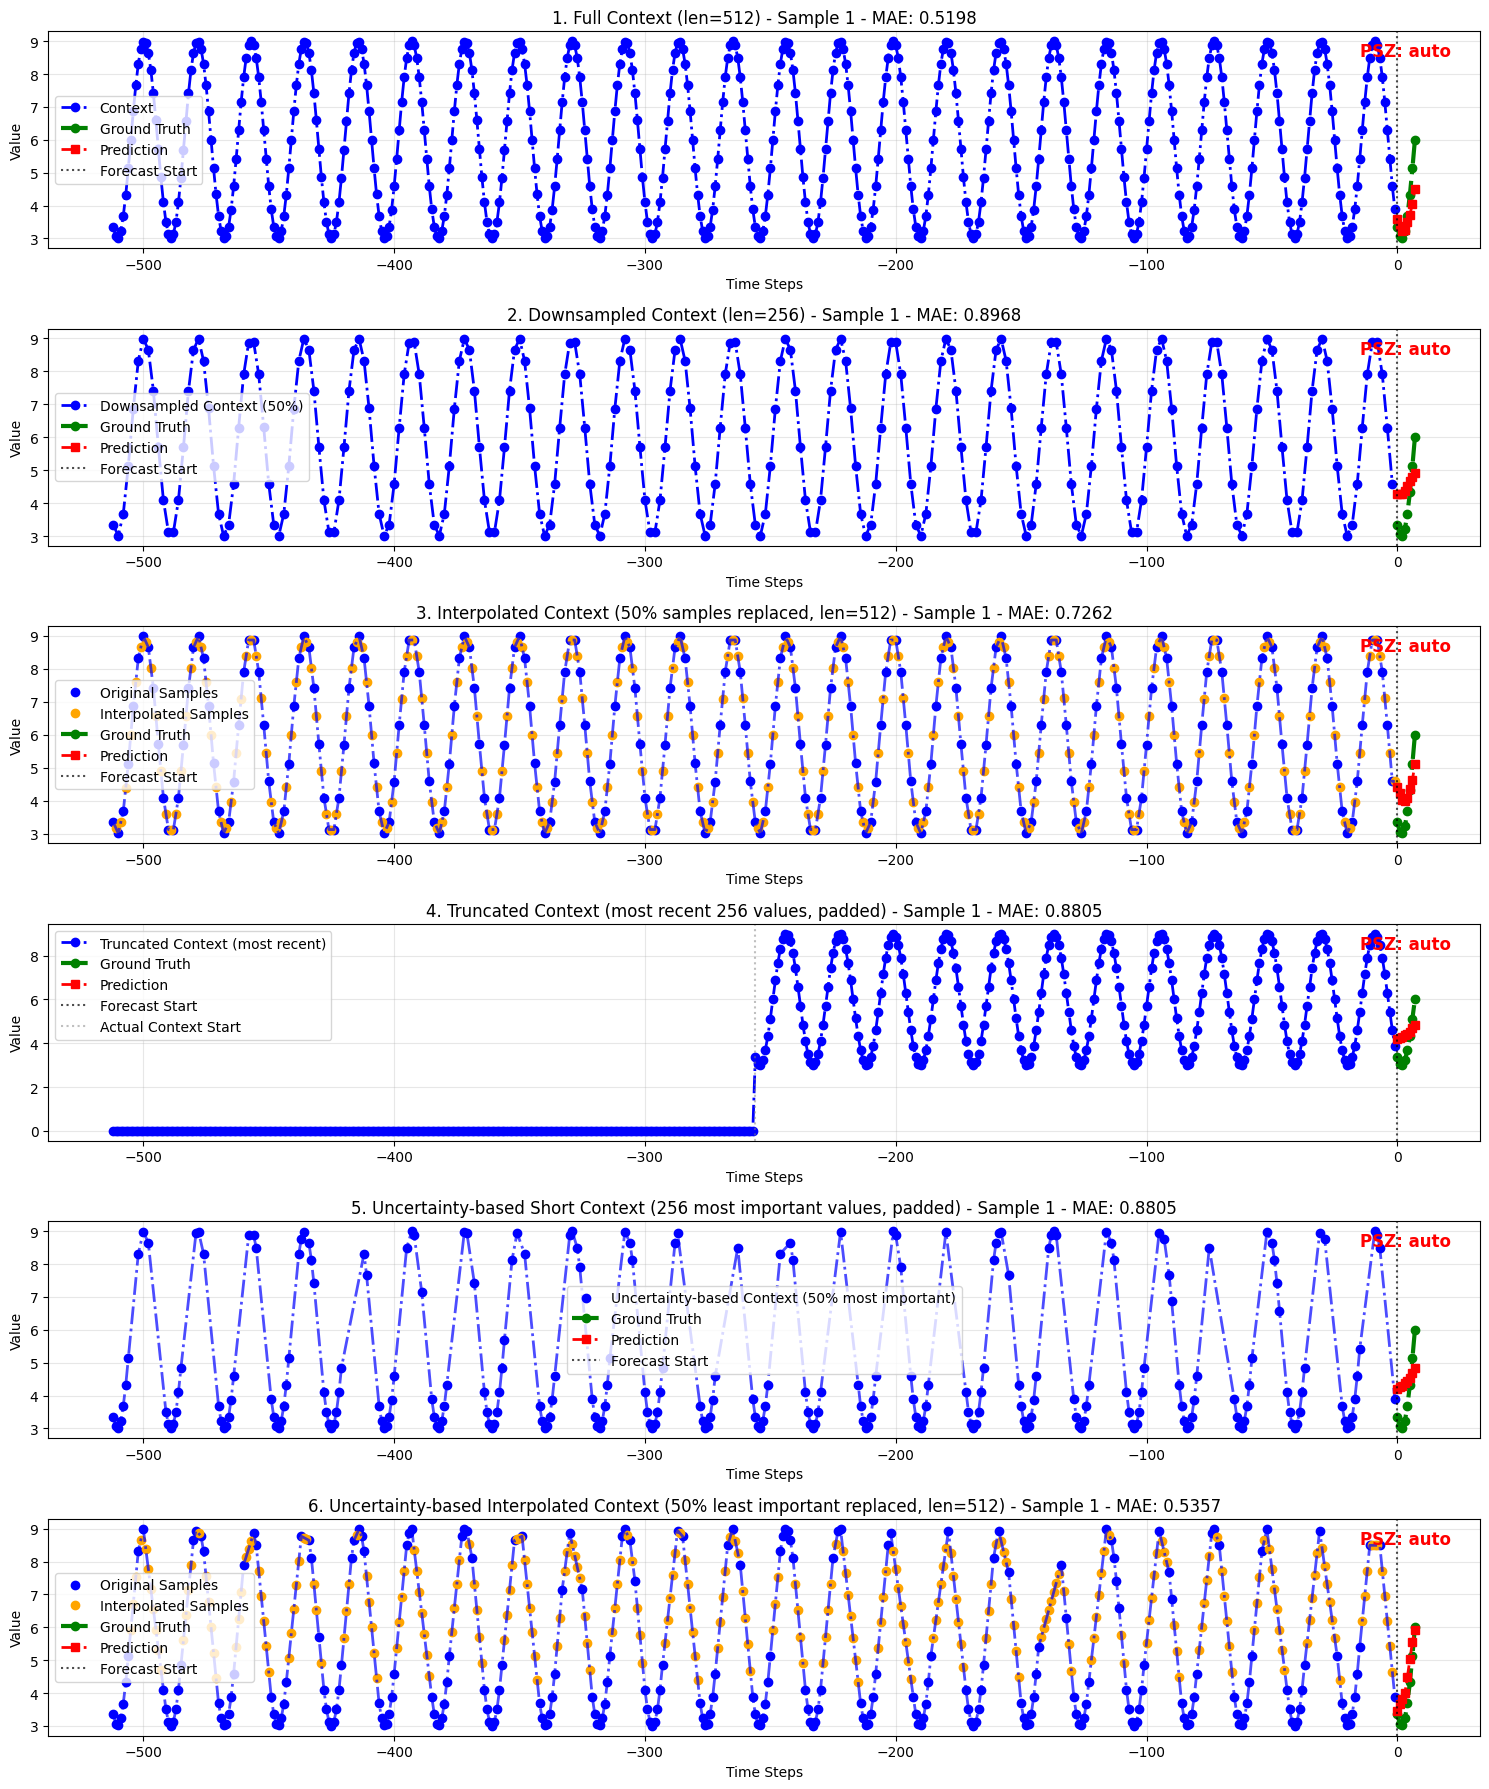

Saved plot: results_prune_1/synthetic_sinusoidal_moirai-large/sample_3_all_methods_comparison.png

Creating summary comparison plot for all methods...


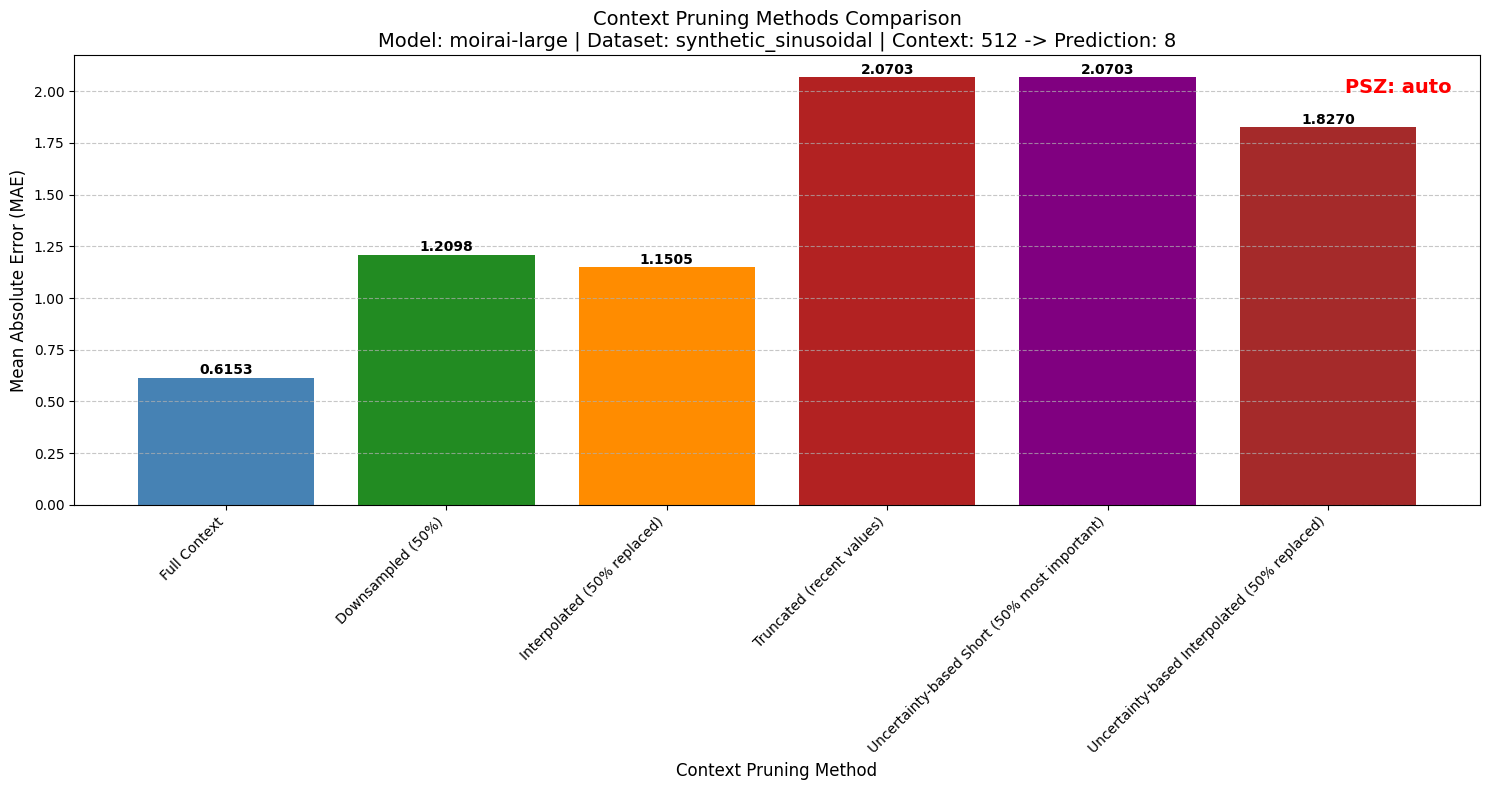

Saved summary plot: results_prune_1/synthetic_sinusoidal_moirai-large/methods_comparison_summary.png

ANALYSIS COMPLETE!
All results and plots saved to: results_prune_1/synthetic_sinusoidal_moirai-large
Best performing method: Full Context (MAE: 0.6153)

Performance relative to Full Context (MAE: 0.6153):
  Downsampled (50%)                       : -96.62% (worse)
  Interpolated (50% replaced)             : -86.98% (worse)
  Truncated (recent values)               : -236.49% (worse)
  Uncertainty-based Short (50% most important): -236.49% (worse)
  Uncertainty-based Interpolated (50% replaced): -196.94% (worse)


In [3]:
# Plot results for all pruning methods including uncertainty-based approaches
# For 3 random samples, plot context, ground truth and prediction for all 6 methods
num_samples = 3
sample_indices = np.random.choice(len(sample_results), num_samples, replace=False)

for plot_idx, idx in enumerate(sample_indices, 1):
    # Get results for all methods
    result = sample_results[idx]
    result_downsampled = sample_results_downsampled[idx]
    result_interpolated = sample_results_interpolated[idx]
    result_truncated = sample_results_truncated[idx]
    result_uncertainty_short = sample_results_uncertainty_short[idx]
    result_uncertainty_interpolated = sample_results_uncertainty_interpolated[idx]
    
    plt.figure(figsize=(15, 18))  # Increased height for 6 subplots
    
    # 1. Full context
    plt.subplot(6, 1, 1)
    context_len = len(result['context'])
    context_indices = np.arange(-context_len, 0)
    forecast_indices = np.arange(0, PDT)
    
    plt.plot(context_indices, result['context'], label='Context', color='blue', linewidth=2, 
             linestyle='-.', marker='o', markersize=6)
    plt.plot(forecast_indices, result['ground_truth'], label='Ground Truth', color='green', 
             linewidth=3, marker='o', markersize=6, linestyle='-.')
    plt.plot(forecast_indices, result['prediction'], label='Prediction', color='red', 
             linewidth=2, linestyle='-.', marker='s', markersize=6)
    plt.axvline(x=0, color='black', linestyle=':', alpha=0.7, label='Forecast Start')
    
    # Add patch size in red text on top right
    plt.text(0.98, 0.95, f'PSZ: {PSZ}', transform=plt.gca().transAxes, color='red', 
             fontsize=12, fontweight='bold', ha='right', va='top')
    
    plt.title(f"1. Full Context (len={context_len}) - Sample {result['window_id']} - MAE: {result['mae']:.4f}")
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. Downsampled context - maintain time scale
    plt.subplot(6, 1, 2)
    context_len_reduced = len(result_downsampled['context'])
    
    # Maintain original time scale by spacing the downsampled points appropriately
    # Since we took every 2nd sample, place them at positions corresponding to original indices
    downsampled_indices = np.arange(-context_len_reduced*2, 0, 2)  # Every 2nd position
    
    plt.plot(downsampled_indices, result_downsampled['context'], label='Downsampled Context (50%)', 
             color='blue', linewidth=2, linestyle='-.', marker='o', markersize=6)
    plt.plot(forecast_indices, result_downsampled['ground_truth'], label='Ground Truth', color='green', 
             linewidth=3, marker='o', markersize=6, linestyle='-.')
    plt.plot(forecast_indices, result_downsampled['prediction'], label='Prediction', color='red', 
             linewidth=2, linestyle='-.', marker='s', markersize=6)
    plt.axvline(x=0, color='black', linestyle=':', alpha=0.7, label='Forecast Start')
    
    # Add patch size in red text on top right
    plt.text(0.98, 0.95, f'PSZ: {PSZ}', transform=plt.gca().transAxes, color='red', 
             fontsize=12, fontweight='bold', ha='right', va='top')
    
    plt.title(f"2. Downsampled Context (len={context_len_reduced}) - Sample {result_downsampled['window_id']} - MAE: {result_downsampled['mae']:.4f}")
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. Interpolated context (50% replaced) - highlight interpolated samples
    plt.subplot(6, 1, 3)
    context_len_interpolated = len(result_interpolated['context'])
    context_indices_interpolated = np.arange(-context_len_interpolated, 0)
    
    # Get the original data to identify which samples were interpolated
    original_context = input_data[idx]['target'][-context_len_interpolated:]
    interpolated_context = result_interpolated['context']
    
    # Find interpolated positions (where values differ significantly from original)
    interpolated_mask = np.abs(interpolated_context - original_context) > 1e-6
    
    # Plot original samples in blue
    plt.plot(context_indices_interpolated[~interpolated_mask], 
             interpolated_context[~interpolated_mask], 
             'o', color='blue', markersize=6, label='Original Samples')
    
    # Plot interpolated samples in orange
    plt.plot(context_indices_interpolated[interpolated_mask], 
             interpolated_context[interpolated_mask], 
             'o', color='orange', markersize=6, label='Interpolated Samples')
    
    # Connect all points with a line
    plt.plot(context_indices_interpolated, interpolated_context, 
             color='blue', linewidth=2, linestyle='-.', alpha=0.7)
    
    plt.plot(forecast_indices, result_interpolated['ground_truth'], label='Ground Truth', 
             color='green', linewidth=3, marker='o', markersize=6, linestyle='-.')
    plt.plot(forecast_indices, result_interpolated['prediction'], label='Prediction', 
             color='red', linewidth=2, linestyle='-.', marker='s', markersize=6)
    plt.axvline(x=0, color='black', linestyle=':', alpha=0.7, label='Forecast Start')
    
    # Add patch size in red text on top right
    plt.text(0.98, 0.95, f'PSZ: {PSZ}', transform=plt.gca().transAxes, color='red', 
             fontsize=12, fontweight='bold', ha='right', va='top')
    
    plt.title(f"3. Interpolated Context (50% samples replaced, len={context_len_interpolated}) - Sample {result_interpolated['window_id']} - MAE: {result_interpolated['mae']:.4f}")
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 4. Truncated context (most recent values) - pad with zeros to maintain scale
    plt.subplot(6, 1, 4)
    context_len_truncated = len(result_truncated['context'])
    
    # Pad with zeros to maintain the same scale as full context
    if context_len_truncated < context_len:
        zeros_padding = np.zeros(context_len - context_len_truncated)
        padded_truncated_context = np.concatenate([zeros_padding, result_truncated['context']])
        truncated_indices = np.arange(-context_len, 0)
        context_start_line = -context_len_truncated
    else:
        padded_truncated_context = result_truncated['context']
        truncated_indices = np.arange(-context_len_truncated, 0)
        context_start_line = -context_len_truncated
    
    plt.plot(truncated_indices, padded_truncated_context, label='Truncated Context (most recent)', 
             color='blue', linewidth=2, linestyle='-.', marker='o', markersize=6)
    plt.plot(forecast_indices, result_truncated['ground_truth'], label='Ground Truth', 
             color='green', linewidth=3, marker='o', markersize=6, linestyle='-.')
    plt.plot(forecast_indices, result_truncated['prediction'], label='Prediction', 
             color='red', linewidth=2, linestyle='-.', marker='s', markersize=6)
    plt.axvline(x=0, color='black', linestyle=':', alpha=0.7, label='Forecast Start')
    plt.axvline(x=context_start_line, color='gray', linestyle=':', alpha=0.5, label='Actual Context Start')
    
    # Add patch size in red text on top right
    plt.text(0.98, 0.95, f'PSZ: {PSZ}', transform=plt.gca().transAxes, color='red', 
             fontsize=12, fontweight='bold', ha='right', va='top')
    
    plt.title(f"4. Truncated Context (most recent {context_len_truncated} values, padded) - Sample {result_truncated['window_id']} - MAE: {result_truncated['mae']:.4f}")
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 5. Uncertainty-based short context - maintain time scale with padding
    plt.subplot(6, 1, 5)
    context_len_unc_short = len(result_uncertainty_short['context'])
    
    # For uncertainty-based short context, we need to map the selected important samples
    # back to their original time positions within the last CTX samples
    # Get the original context to determine which samples were kept
    original_last_ctx = input_data[idx]['target'][-CTX:]
    
    # Find which indices were kept by comparing values
    kept_indices = []
    unc_context = result_uncertainty_short['context']
    for i, val in enumerate(unc_context):
        # Find the closest match in the original last CTX samples
        closest_idx = np.argmin(np.abs(original_last_ctx - val))
        kept_indices.append(closest_idx)
    
    # Create time indices for the kept samples (relative to end of context)
    unc_time_indices = np.array(kept_indices) - CTX
    
    # Pad with zeros to maintain scale
    if context_len_unc_short < context_len:
        # Create a padded array with zeros
        padded_unc_context = np.zeros(context_len)
        # Map the kept samples to their correct positions
        for i, (time_idx, val) in enumerate(zip(unc_time_indices, unc_context)):
            padded_unc_context[time_idx + context_len] = val
        
        padded_indices = np.arange(-context_len, 0)
        
        # Plot only non-zero values as points
        non_zero_mask = padded_unc_context != 0
        plt.plot(padded_indices[non_zero_mask], padded_unc_context[non_zero_mask], 
                'o', color='blue', markersize=6, label='Uncertainty-based Context (50% most important)')
        # Connect with lines
        plt.plot(padded_indices[non_zero_mask], padded_unc_context[non_zero_mask], 
                color='blue', linewidth=2, linestyle='-.', alpha=0.7)
    else:
        plt.plot(unc_time_indices, unc_context, 'o-', color='blue', linewidth=2, 
                 linestyle='-.', markersize=6, label='Uncertainty-based Context (50% most important)')
    
    plt.plot(forecast_indices, result_uncertainty_short['ground_truth'], label='Ground Truth', 
             color='green', linewidth=3, marker='o', markersize=6, linestyle='-.')
    plt.plot(forecast_indices, result_uncertainty_short['prediction'], label='Prediction', 
             color='red', linewidth=2, linestyle='-.', marker='s', markersize=6)
    plt.axvline(x=0, color='black', linestyle=':', alpha=0.7, label='Forecast Start')
    
    # Add patch size in red text on top right
    plt.text(0.98, 0.95, f'PSZ: {PSZ}', transform=plt.gca().transAxes, color='red', 
             fontsize=12, fontweight='bold', ha='right', va='top')
    
    plt.title(f"5. Uncertainty-based Short Context ({context_len_unc_short} most important values, padded) - Sample {result_uncertainty_short['window_id']} - MAE: {result_uncertainty_short['mae']:.4f}")
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 6. Uncertainty-based interpolated context - highlight interpolated samples
    plt.subplot(6, 1, 6)
    context_len_unc_interp = len(result_uncertainty_interpolated['context'])
    context_indices_unc_interp = np.arange(-context_len_unc_interp, 0)
    
    # Get the original last CTX samples to identify which were interpolated
    original_last_ctx = input_data[idx]['target'][-CTX:]
    unc_interpolated_context = result_uncertainty_interpolated['context']
    
    # Find interpolated positions (where values differ from original)
    unc_interpolated_mask = np.abs(unc_interpolated_context - original_last_ctx) > 1e-6
    
    # Plot original samples in blue
    plt.plot(context_indices_unc_interp[~unc_interpolated_mask], 
             unc_interpolated_context[~unc_interpolated_mask], 
             'o', color='blue', markersize=6, label='Original Samples')
    
    # Plot interpolated samples in orange
    plt.plot(context_indices_unc_interp[unc_interpolated_mask], 
             unc_interpolated_context[unc_interpolated_mask], 
             'o', color='orange', markersize=6, label='Interpolated Samples')
    
    # Connect all points with a line
    plt.plot(context_indices_unc_interp, unc_interpolated_context, 
             color='blue', linewidth=2, linestyle='-.', alpha=0.7)
    
    plt.plot(forecast_indices, result_uncertainty_interpolated['ground_truth'], label='Ground Truth', 
             color='green', linewidth=3, marker='o', markersize=6, linestyle='-.')
    plt.plot(forecast_indices, result_uncertainty_interpolated['prediction'], label='Prediction', 
             color='red', linewidth=2, linestyle='-.', marker='s', markersize=6)
    plt.axvline(x=0, color='black', linestyle=':', alpha=0.7, label='Forecast Start')
    
    # Add patch size in red text on top right
    plt.text(0.98, 0.95, f'PSZ: {PSZ}', transform=plt.gca().transAxes, color='red', 
             fontsize=12, fontweight='bold', ha='right', va='top')
    
    plt.title(f"6. Uncertainty-based Interpolated Context (50% least important replaced, len={context_len_unc_interp}) - Sample {result_uncertainty_interpolated['window_id']} - MAE: {result_uncertainty_interpolated['mae']:.4f}")
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Save plot
    plot_filename = os.path.join(results_dir, f"sample_{plot_idx}_all_methods_comparison.png")
    plt.tight_layout()
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved plot: {plot_filename}")

# Create summary comparison plot
print("\nCreating summary comparison plot for all methods...")
plt.figure(figsize=(15, 8))

methods = list(methods_summary.keys())
mae_values = list(methods_summary.values())

bars = plt.bar(range(len(methods)), mae_values, 
               color=['steelblue', 'forestgreen', 'darkorange', 'firebrick', 'purple', 'brown'])

# Add MAE values on top of bars
for i, (bar, mae) in enumerate(zip(bars, mae_values)):
    plt.text(bar.get_x() + bar.get_width()/2.0, bar.get_height() + 0.001, 
             f'{mae:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Context Pruning Method', fontsize=12)
plt.ylabel('Mean Absolute Error (MAE)', fontsize=12)

# Add patch size in red text on top right of the summary plot
plt.text(0.98, 0.95, f'PSZ: {PSZ}', transform=plt.gca().transAxes, color='red', 
         fontsize=14, fontweight='bold', ha='right', va='top')

plt.title(f'Context Pruning Methods Comparison\nModel: {MODEL}-{SIZE} | Dataset: {dataset_name} | Context: {CTX} -> Prediction: {PDT}', fontsize=14)
plt.xticks(range(len(methods)), methods, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save summary plot
summary_filename = os.path.join(results_dir, "methods_comparison_summary.png")
plt.savefig(summary_filename, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved summary plot: {summary_filename}")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print(f"All results and plots saved to: {results_dir}")
print(f"Best performing method: {best_method[0]} (MAE: {best_method[1]:.4f})")

# Calculate improvement percentages
full_context_mae = methods_summary['Full Context']
print(f"\nPerformance relative to Full Context (MAE: {full_context_mae:.4f}):")
for method, mae in methods_summary.items():
    if method != 'Full Context':
        improvement = ((full_context_mae - mae) / full_context_mae) * 100
        status = "better" if improvement > 0 else "worse"
        print(f"  {method:<40}: {improvement:+.2f}% ({status})")


In [4]:
# Create uncertainty and delta analysis plots for the 3 selected samples
print("\nCreating uncertainty and delta analysis plots for selected samples...")

# Select 3 random samples for detailed analysis
num_samples = 3
sample_indices = np.random.choice(len(sample_results), num_samples, replace=False)

for plot_idx, idx in enumerate(sample_indices, 1):
    # Get the stored uncertainty data for this sample
    if idx in selected_samples_data:
        sample_data = selected_samples_data[idx]
        signal = sample_data['signal']
        uncertainty = sample_data['uncertainty']
        delta = sample_data['delta']  # delta[i] = x[i] - x[i-1], delta[0] = 0
        
        # Create figure with 2 subplots for each sample
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
        
        # Plot 1: Signal and Uncertainty Map
        ax1_twin = ax1.twinx()  # Create twin axis for uncertainty
        
        # Plot the signal (last CTX samples)
        ctx_indices = np.arange(-CTX, 0)
        line1 = ax1.plot(ctx_indices, signal, 'o-', color='blue', linewidth=2, 
                        linestyle='-.', markersize=6, label='Signal (Context)')
        ax1.set_xlabel('Time Steps')
        ax1.set_ylabel('Signal Value', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.grid(True, alpha=0.3)
        
        # Plot the uncertainty map
        line2 = ax1_twin.plot(ctx_indices, uncertainty, 's-', color='red', linewidth=2, 
                             linestyle='-.', markersize=6, alpha=0.7, label='Uncertainty')
        ax1_twin.set_ylabel('Uncertainty Score', color='red')
        ax1_twin.tick_params(axis='y', labelcolor='red')
        
        # Add patch size in red text on top right
        ax1.text(0.98, 0.95, f'PSZ: {PSZ}', transform=ax1.transAxes, color='red', 
                fontsize=12, fontweight='bold', ha='right', va='top')
        
        # Create combined legend
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax1_twin.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        
        ax1.set_title(f'Signal and Uncertainty Map - Sample {plot_idx} (Window {sample_results[idx]["window_id"]})')
        
        # Plot 2: Delta and Uncertainty Map
        ax2_twin = ax2.twinx()  # Create twin axis for uncertainty
        
        # Plot deltas: delta[i] = x[i] - x[i-1] at position i
        # We skip the first position (i=0) since delta[0] = 0 (no previous value)
        delta_positions = ctx_indices[1:]  # Skip first position
        delta_values = delta[1:]  # Skip delta[0] which is 0
        uncertainty_for_delta = uncertainty[1:]  # Corresponding uncertainty values
        
        line3 = ax2.plot(delta_positions, delta_values, 'o-', color='green', linewidth=2, 
                        linestyle='-.', markersize=6, label='Signal Delta (xi - xi-1)')
        ax2.axhline(y=0, color='black', linestyle=':', alpha=0.5, label='Zero Line')
        ax2.set_xlabel('Time Steps')
        ax2.set_ylabel('Delta Value', color='green')
        ax2.tick_params(axis='y', labelcolor='green')
        ax2.grid(True, alpha=0.3)
        
        # Plot the uncertainty map for delta positions
        line4 = ax2_twin.plot(delta_positions, uncertainty_for_delta, 's-', color='red', linewidth=2, 
                             linestyle='-.', markersize=6, alpha=0.7, label='Uncertainty')
        ax2_twin.set_ylabel('Uncertainty Score', color='red')
        ax2_twin.tick_params(axis='y', labelcolor='red')
        
        # Add patch size in red text on top right
        ax2.text(0.98, 0.95, f'PSZ: {PSZ}', transform=ax2.transAxes, color='red', 
                fontsize=12, fontweight='bold', ha='right', va='top')
        
        # Create combined legend
        lines3, labels3 = ax2.get_legend_handles_labels()
        lines4, labels4 = ax2_twin.get_legend_handles_labels()
        ax2.legend(lines3 + lines4, labels3 + labels4, loc='upper left')
        
        ax2.set_title(f'Signal Delta and Uncertainty Map - Sample {plot_idx} (Window {sample_results[idx]["window_id"]})')
        
        # Save the uncertainty and delta analysis plot
        uncertainty_plot_filename = os.path.join(results_dir, f"sample_{plot_idx}_uncertainty_delta_analysis.png")
        plt.tight_layout()
        plt.savefig(uncertainty_plot_filename, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved uncertainty and delta analysis plot: {uncertainty_plot_filename}")
        
    else:
        print(f"Warning: No uncertainty data available for sample {idx} (plot {plot_idx})")

print("\nUncertainty and delta analysis complete!")


Creating uncertainty and delta analysis plots for selected samples...


NameError: name 'selected_samples_data' is not defined